<a href="https://colab.research.google.com/github/Jenycantik/Kalkulator_/blob/main/CNN_Covid_Test_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ==========================================
# BLOK 0: Menghubungkan Google Colab dengan Google Drive
# Tujuan: Mengakses dataset yang tersimpan di Drive
# ==========================================

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# ==========================================
# BLOK 1: Import library untuk inference model
# Tujuan: Menyiapkan tools untuk load model dan prediksi gambar baru
# ==========================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from google.colab import files

In [6]:
# ==========================================
# BLOK 2: Load model CNN yang sudah dilatih
# Tujuan: Menggunakan model tanpa training ulang
# ==========================================

model = tf.keras.models.load_model('/content/drive/MyDrive/CVN/model/cnn_covid_multiclass.h5')

print("Model berhasil dimuat!")

Model berhasil dimuat!


In [11]:
# ==========================================
# BLOK 4: Upload gambar dari laptop user
# Tujuan: Memungkinkan user memilih file gambar secara manual
# ==========================================

uploaded = files.upload()

Saving 0111.jpeg to 0111.jpeg


In [12]:
# ==========================================
# BLOK 5: Preprocessing gambar input
# Tujuan:
# - Resize gambar ke ukuran input CNN (224x224)
# - Normalisasi pixel (0-1)
# ==========================================

for img_name in uploaded.keys():
    img_path = img_name

    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

In [13]:
# ==========================================
# BLOK 6: Melakukan prediksi
# Tujuan: Menghasilkan probabilitas untuk setiap kelas
# ==========================================

class_names = ['covid', 'normal', 'pneumonia']
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction, axis=1)[0]
confidence = np.max(prediction)

print("Prediksi kelas:", class_names[predicted_class])
print("Confidence:", confidence)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
Prediksi kelas: pneumonia
Confidence: 0.8490091


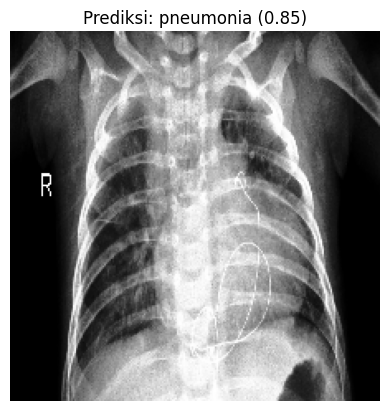

In [14]:
# ==========================================
# BLOK 7: Menampilkan gambar dan hasil prediksi
# Tujuan: Memberikan interpretasi visual kepada user
# ==========================================

plt.imshow(img)
plt.title(f"Prediksi: {class_names[predicted_class]} ({confidence:.2f})")
plt.axis('off')
plt.show()